Importing Libraries

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


Image visualization

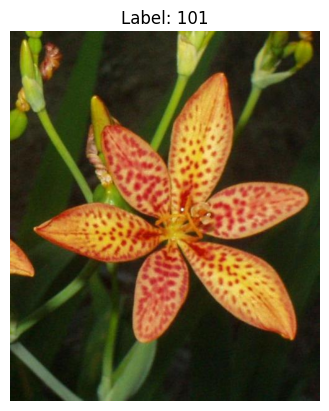

In [65]:
raw_dataset = datasets.Flowers102(
    root="./data",
    split="train",
    download=False
)

img, label = raw_dataset[1019]

plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

Image Transformations

In [66]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225]
    )
])

Visualization After Transformation

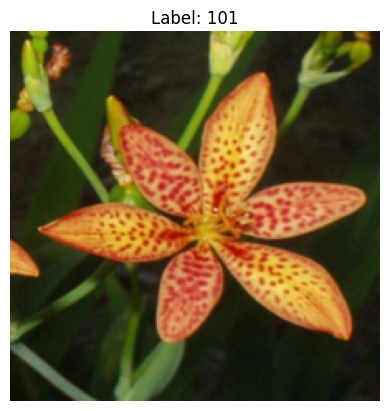

In [67]:
img, label = train_dataset[1019]

# undo normalization
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

img = img.permute(1,2,0).numpy()
img = img * std + mean
img = img.clip(0,1)

plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

Loading Dataset

In [68]:
train_dataset = datasets.Flowers102(
    root='./data',
    split = 'train',
    download=True,
    transform = transform
)

val_dataset = datasets.Flowers102(
    root= './data',
    split= 'val',
    download=True,
    transform=transform
)

test_dataset = datasets.Flowers102(
    root= './data',
    split='test',
    download=True,
    transform=transform
)

In [69]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

1020
1020
6149


Creating Dataloaders

In [70]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [71]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


Loading pretrained model

In [72]:
model = models.resnet50(pretrained=True)

c:\Users\vikas g\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\vikas g\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [73]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [74]:
print(model.fc)

Linear(in_features=2048, out_features=1000, bias=True)


Freezing pretrained layers

In [75]:
for param in model.parameters():
    param.requires_grad = False

Replacing Final Layer

In [76]:
num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 102)

In [77]:
model = model.to(device)

In [78]:
print(model.fc)

Linear(in_features=2048, out_features=102, bias=True)


Defining Loss Function

In [79]:
criterion = nn.CrossEntropyLoss()

Defining optimizer

In [80]:
optimizer = optim.Adam(
    model.fc.parameters(),
    lr = 0.001
)

epochs = 10

Training and Validation Loop

In [81]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [82]:
for epoch in range(epochs):

    # -------- TRAINING --------
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    # -------- VALIDATION --------
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()


    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)


    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_accuracy:.2f}% | "
          f"Val Acc: {val_accuracy:.2f}%")

Epoch [1/10] | Train Loss: 4.6152 | Val Loss: 3.5038 | Train Acc: 7.45% | Val Acc: 30.49%
Epoch [2/10] | Train Loss: 2.6917 | Val Loss: 2.3758 | Train Acc: 56.08% | Val Acc: 56.37%
Epoch [3/10] | Train Loss: 1.5940 | Val Loss: 1.7590 | Train Acc: 79.12% | Val Acc: 69.41%
Epoch [4/10] | Train Loss: 1.0070 | Val Loss: 1.3753 | Train Acc: 90.00% | Val Acc: 76.67%
Epoch [5/10] | Train Loss: 0.6738 | Val Loss: 1.1801 | Train Acc: 95.10% | Val Acc: 78.82%
Epoch [6/10] | Train Loss: 0.4706 | Val Loss: 1.0353 | Train Acc: 97.16% | Val Acc: 80.88%
Epoch [7/10] | Train Loss: 0.3613 | Val Loss: 0.9297 | Train Acc: 98.82% | Val Acc: 83.04%
Epoch [8/10] | Train Loss: 0.2722 | Val Loss: 0.8756 | Train Acc: 98.92% | Val Acc: 84.02%
Epoch [9/10] | Train Loss: 0.2196 | Val Loss: 0.8329 | Train Acc: 99.51% | Val Acc: 83.43%
Epoch [10/10] | Train Loss: 0.1737 | Val Loss: 0.7988 | Train Acc: 99.80% | Val Acc: 83.63%


Plotting Learning Curves

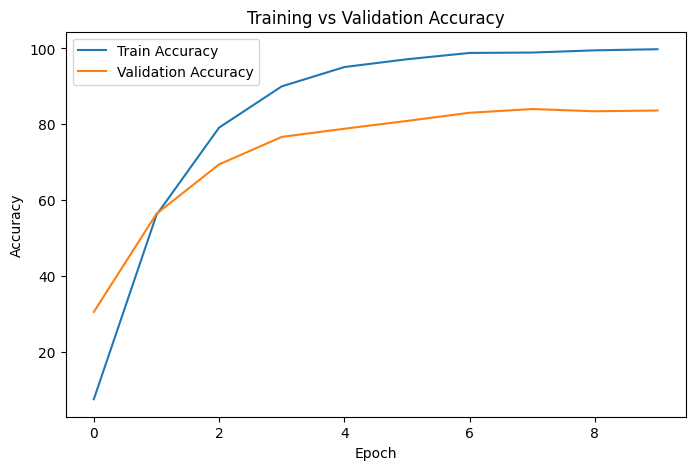

In [86]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

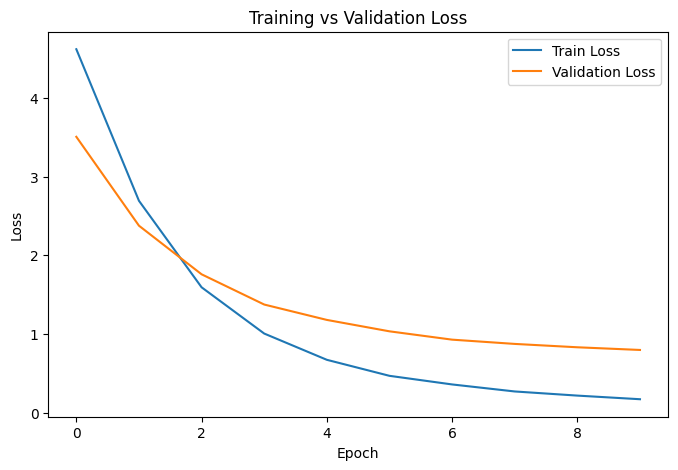

In [87]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

Test Accuracy

In [85]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("Test Accuracy:", test_accuracy)

Test Accuracy: 80.98877866319727
